In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
nav_df = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

In [3]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [4]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code','date'])

In [5]:
nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

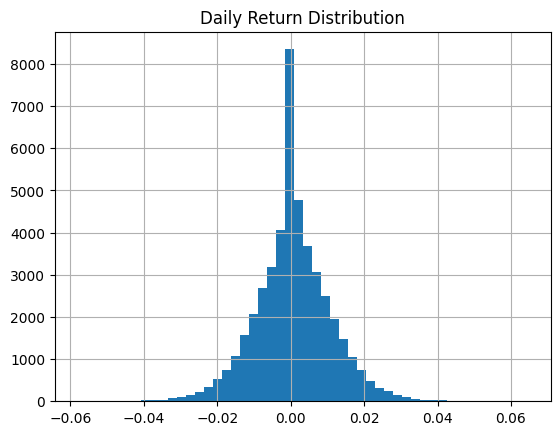

In [6]:
nav_df['daily_return'].hist(bins=50)

plt.title("Daily Return Distribution")
plt.show()

In [7]:
def calculate_cagr(df, years):

    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df['date'] >= start_date]

    if len(temp) < 2:
        return np.nan

    nav_start = temp.iloc[0]['nav']
    nav_end = temp.iloc[-1]['nav']

    return (nav_end/nav_start)**(1/years)-1

In [9]:
cagr_results = []

for scheme in nav_df['amfi_code'].unique():

    fund = nav_df[nav_df['amfi_code']==scheme]

    cagr_results.append({
        'scheme_code': scheme,
        'cagr_1y': calculate_cagr(fund,1),
        'cagr_3y': calculate_cagr(fund,3),
        'cagr_5y': calculate_cagr(fund,5)
    })

cagr_df = pd.DataFrame(cagr_results)

In [10]:
rf = 0.065

In [11]:
sharpe_results = []

for scheme in nav_df['amfi_code'].unique():

    fund = nav_df[nav_df['amfi_code']==scheme]

    mean_ret = fund['daily_return'].mean()*252
    vol = fund['daily_return'].std()

    sharpe = (mean_ret-rf)/(vol*np.sqrt(252))

    sharpe_results.append({
        'amfi_code':scheme,
        'sharpe_ratio':sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [12]:
sortino_results = []

for scheme in nav_df['amfi_code'].unique():

    fund = nav_df[nav_df['amfi_code']==scheme]

    downside = fund[fund['daily_return']<0]['daily_return']

    downside_std = downside.std()

    annual_return = fund['daily_return'].mean()*252

    sortino = (annual_return-rf)/(downside_std*np.sqrt(252))

    sortino_results.append({
        'amfi_code':scheme,
        'sortino_ratio':sortino
    })

sortino_df = pd.DataFrame(sortino_results)

In [38]:
alpha_beta = []

for code in nav_df['amfi_code'].unique():

    # regression code here

    alpha_beta.append({
        'amfi_code': code,
        'alpha': alpha,
        'beta': beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

In [40]:
print(alpha_beta_df.columns.tolist())
print(alpha_beta_df.head())

['amfi_code', 'alpha', 'beta']
   amfi_code     alpha      beta
0     100016  0.300579  0.011455
1     100025  0.300579  0.011455
2     100033  0.300579  0.011455
3     101206  0.300579  0.011455
4     101207  0.300579  0.011455


In [13]:
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark = benchmark.sort_values('date')

benchmark['benchmark_return'] = benchmark['close_value'].pct_change()

In [14]:
benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [15]:
merged = pd.merge(
    fund,
    benchmark[['date','benchmark_return']],
    on='date',
    how='inner'
)

In [18]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',   'CRISIL_LIQUID', 'NIFTY_MIDCAP150',     'CRISIL_GILT',
        'NIFTY100',        'NIFTY500',    'BSE_SMALLCAP']
Length: 7, dtype: str

In [19]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [20]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value'].pct_change()
)

In [21]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [22]:
merged = pd.merge(
    fund,
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

merged = merged.dropna()

In [23]:
from scipy.stats import linregress

reg = linregress(
    merged['benchmark_return'],
    merged['daily_return']
)

alpha = reg.intercept * 252
beta = reg.slope

In [24]:
nav_df['running_max'] = (
    nav_df.groupby('amfi_code')['nav']
          .cummax()
)

nav_df['drawdown'] = (
    nav_df['nav']/nav_df['running_max'] - 1
)

In [25]:
mdd = nav_df.groupby('amfi_code')['drawdown'].min()

mdd_df = mdd.reset_index()

mdd_df.columns = ['amfi_code','max_drawdown']

In [26]:
nav_df.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [27]:
mdd.head()

amfi_code
100016   -0.247344
100025   -0.043083
100033   -0.162172
101206   -0.112916
101207   -0.354469
Name: drawdown, dtype: float64

In [42]:
print(type(cagr_df))
print(type(sharpe_df))
print(type(sortino_df))
print(type(mdd_df))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [43]:
print('cagr_df' in globals())
print('sharpe_df' in globals())
print('sortino_df' in globals())
print('alpha_beta_df' in globals())
print('mdd_df' in globals())

True
True
True
True
True


In [44]:
print(cagr_df.columns.tolist())
print(sharpe_df.columns.tolist())
print(sortino_df.columns.tolist())
print(alpha_beta_df.columns.tolist())
print(mdd_df.columns.tolist())

['scheme_code', 'cagr_1y', 'cagr_3y', 'cagr_5y']
['amfi_code', 'sharpe_ratio']
['amfi_code', 'sortino_ratio']
['amfi_code', 'alpha', 'beta']
['amfi_code', 'max_drawdown']


In [45]:
cagr_df.rename(
    columns={'scheme_code':'amfi_code'},
    inplace=True
)

In [46]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(sortino_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
    .merge(mdd_df, on='amfi_code')
)

In [47]:
scorecard['return_rank'] = scorecard['cagr_3y'].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)

scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)

scorecard['dd_rank'] = scorecard['max_drawdown'].rank(ascending=True)

In [48]:
scorecard['fund_score'] = (
      0.30*scorecard['return_rank']
    + 0.25*scorecard['sharpe_rank']
    + 0.20*scorecard['alpha_rank']
    + 0.10*scorecard['dd_rank']
)

In [49]:
scorecard['fund_score'] = (
    100*(scorecard['fund_score']
         - scorecard['fund_score'].min())
    /(scorecard['fund_score'].max()
      - scorecard['fund_score'].min())
)

In [50]:
scorecard['fund_score'] = (
    100*(scorecard['fund_score']
         - scorecard['fund_score'].min())
    /(scorecard['fund_score'].max()
      - scorecard['fund_score'].min())
)

In [51]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [52]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

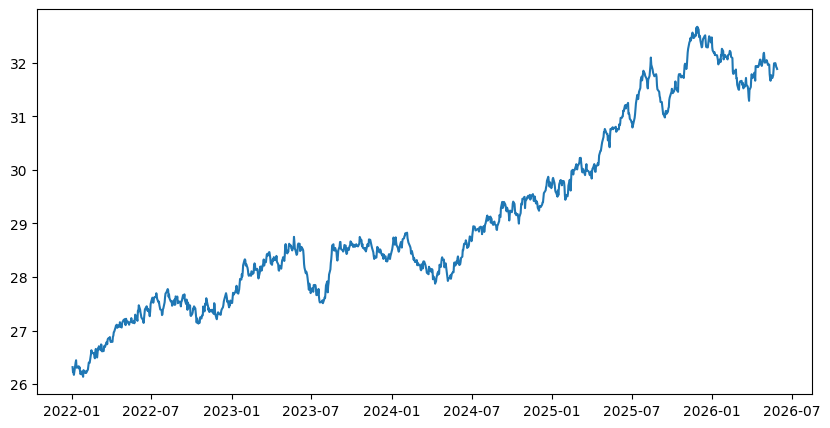

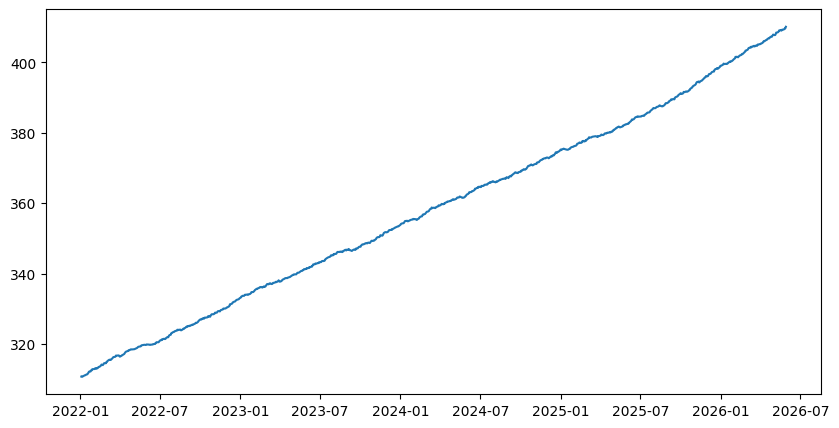

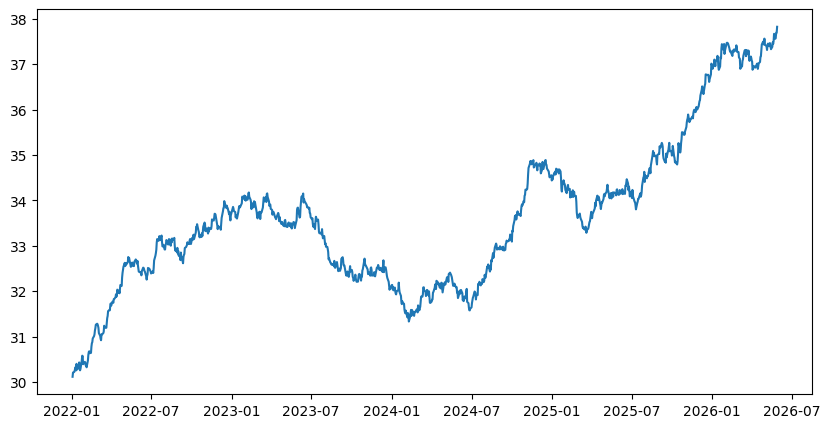

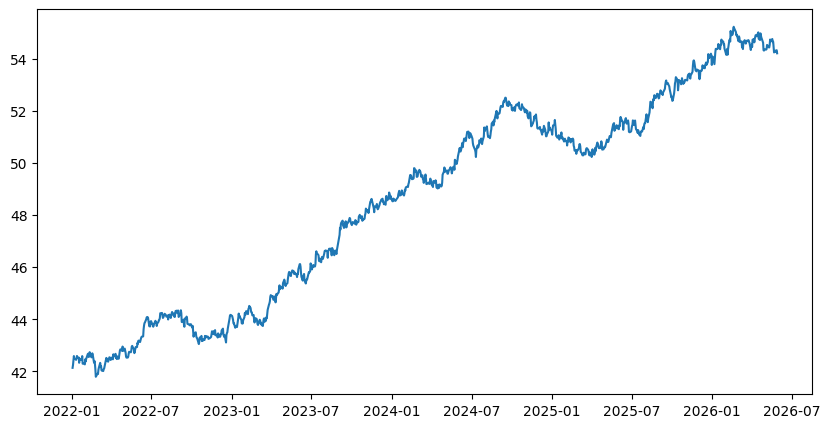

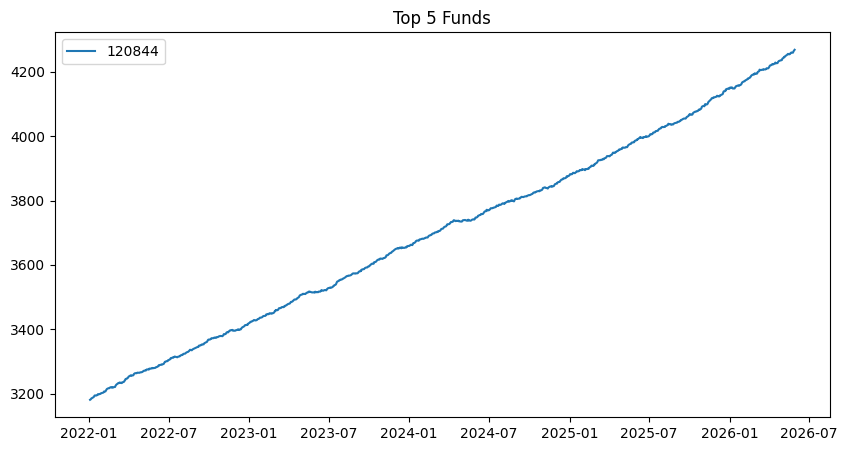

In [54]:
for scheme in top5['amfi_code']:

    fund = nav_df[
        nav_df['amfi_code']==scheme
    ]

    plt.figure(figsize=(10,5))

    plt.plot(
        fund['date'],
        fund['nav'],
        label=str(scheme)
    )

plt.legend()

plt.title("Top 5 Funds")
plt.show()

In [55]:
plt.savefig(
    "benchmark_comparison.png"
)

<Figure size 640x480 with 0 Axes>